# Lag Models

## This script accomplishes the following:

In this script, we will run 2 models, to predict the number of conflicts in each ZIP code, in each month.
The predictions are generated in a traditional ML way. We split the data into train and test sets, train the random forest on the former and  make the predicictions on the later.
Hence, we mask data that we "already saw", and then evaluate the models performance by taking the deviation from our predictions to the actual data.

In this script, we **predict**, we don't **forecast**, as the data is present and has already taken place, hence giving us a way to actually evaluate the model.

## Find the following steps below:

1. **Random Forest Model**

- Define features and label (number of conflicts, for each ZIP in PA, for each month)
- Perform 5-fold time-series-cross-validation
- Split the data 70/30 train and test
- Normalize the sets
- Define the rf regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

2. **XGBoost Model**

- Define the xgb regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from joblib import dump, load
import joblib


In [2]:
#Dynamic search path configuration
import sys
import os

#Adjusting search path based on notebook's depth in directory --> iterates through directories until it finds directory name: US_conflict_forecasting
current_dir = os.getcwd()
while 'US_conflict_forecasting' not in os.path.basename(current_dir):
    current_dir = os.path.dirname(current_dir)

#Adjusting search path based on 'new' current directory
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from project_setup import setup_project
project_root_dir = setup_project()

Current Project Root Directory set to: /Users/danie/Desktop/Hertie/2. Semester/1. ML/0. Final Project/US_conflict_forecasting
Current Search Path set to: ['c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting', 'c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting\\3_Models', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32\\lib', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\Pythonwin', 'c:\\Users\\danie\\AppData\

### Load the data

In [3]:
# Load the data

data = pd.read_csv(os.path.join(project_root_dir, '2_Dataset/d_Final_Dataset/Final_Dataset_noLag_clean.csv'))


## 1. Random Forest

### Features and labels, cross-validation, split and normalization

In [4]:
train = data[data['month'] <= 9]

test = data[data['month'] > 9]

In [5]:
X_train = train.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_train = train['event_count']


X_test = test.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_test = test['event_count']

In [6]:
# Time Series Cross Validation, 5 folds.

tscv = TimeSeriesSplit(n_splits=5)

In [7]:
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Define the regressor and run

In [8]:
rf_regressor = RandomForestRegressor(n_estimators = 100, random_state = 100)

In [9]:
rf_regressor.fit(X_train_scaled, Y_train)

RandomForestRegressor(random_state=100)

### Feature importance

In [10]:
# Which are the most important features?

feature_importances = rf_regressor.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

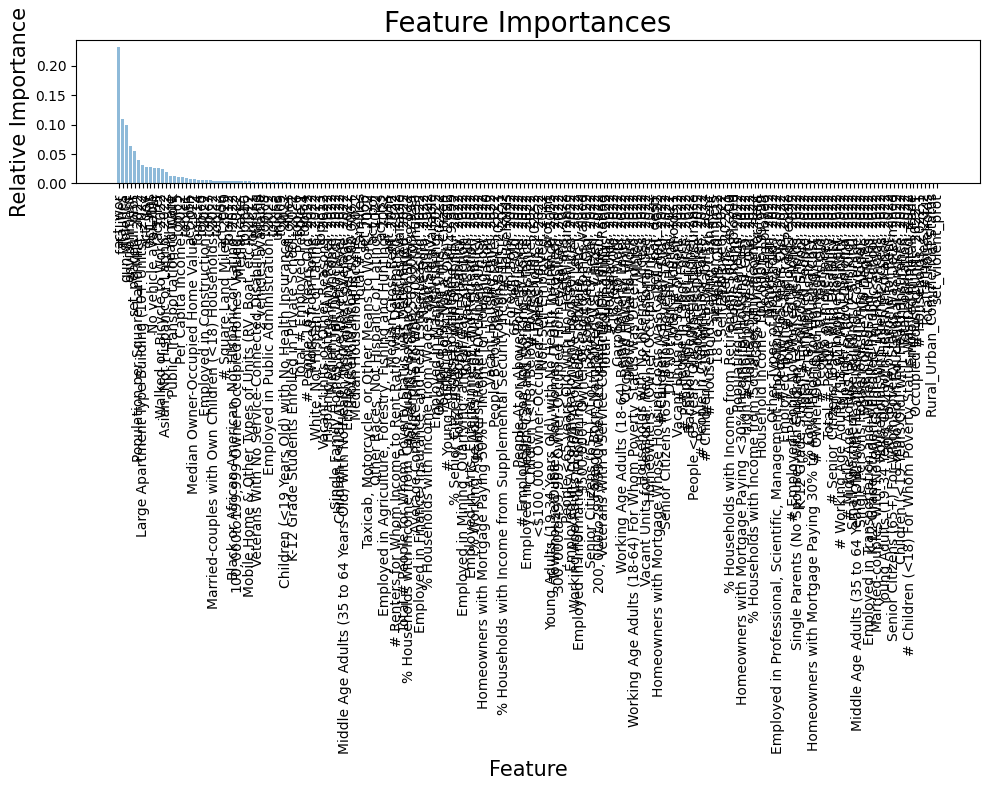

In [11]:
# Assuming rf is your trained RandomForestClassifier
feature_importances = rf_regressor.feature_importances_

# Adjusting feature_names to match your processed 'carseats' DataFrame
# Ensure this line comes after all preprocessing steps, including get_dummies and drop
feature_names = X_train.columns

# Sort the feature importances in descending order and get their indices
sorted_indices = np.argsort(feature_importances)[::-1]

# Create the plot
plt.figure(figsize=(10, 8))
plt.title('Feature Importances', fontsize=20)
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align='center', alpha=0.5)
plt.xticks(range(len(feature_importances)), feature_names[sorted_indices], rotation=90)
plt.ylabel('Relative Importance', fontsize=15)
plt.xlabel('Feature', fontsize=15)
plt.tight_layout()  # Adjusts the plot to ensure everything fits without overlapping
plt.show()

In [12]:
# Print the 10 most important features

for i in range(20):
    print(f'{feature_names[sorted_indices[i]]}: {feature_importances[sorted_indices[i]]}')

act_wor: 0.23174989455957373
fatalities: 0.10906863545536866
gun-violence: 0.09886360009634827
environment: 0.06390158839216395
set_peaceful_prot: 0.05510936485823085
Population per Square Land Mile, 2022: 0.039551870260052635
Large Apartment Type Building (10+ Units), 2022: 0.03133776970947503
act_gov: 0.02855565286872452
act_nat: 0.027604321249237392
No vehicle available: 0.026769780314355916
act_rel: 0.026234179760334948
Walked or Bicycle to Work, 2022: 0.024297576025764746
Asian, Not Hispanic or Latino, 2022: 0.01876838468979549
healthcare: 0.012791182753241386
Public Transportation to Work: 0.012642758674333225
topic5: 0.011846730168824008
Per Capita Income, 2022: 0.010535190768299094
topic1: 0.009076868812400902
act_oth: 0.007107121505227556
Median Owner-Occupied Home Value, 2022: 0.006889280033601841


### Run Grid Search to find the best parameters

In [13]:
# Grid Search for best parameters

# Adjust number of trees in forest, max depth of trees, and minimum samples per leaf

# n_estimators: Number of trees in the forest, to take into account for the prediction
# max_depth: Maximum depth of the tree. From root to leaf, basically controls complexity of the tree and can lead/prevent overfitting. The more splits, the more complex the tree and the more likely to fit noise.
# min_samples_split: Minimum number of samples required to split an internal node


# Prevents overfitting and improves the generalization of the model

param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 7, 9]
}

In [14]:
cv_rf = GridSearchCV(estimator=rf_regressor, param_grid=param_grid_rf, cv = tscv, n_jobs=-1)
cv_rf.fit(X_train_scaled, Y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=100), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [20, 30]})

## Run the predictions

### Without Best Parameters

In [15]:
Y_pred_rf = rf_regressor.predict(X_test_scaled)

predictions_rf = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred_rf})
print(Y_pred_rf)

[0. 0. 0. ... 0. 0. 0.]


In [16]:
mse_rf = mean_squared_error(Y_test, Y_pred_rf)

print('Mean Squared Error:', mse_rf)

Mean Squared Error: 0.13530883797054008


### Including the Best Parameters

In [17]:
Y_pred_gs = cv_rf.predict(X_test_scaled)

predictions_gs = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred_gs})
print(Y_pred_gs)

[0. 0. 0. ... 0. 0. 0.]


In [18]:
mse_gs = mean_squared_error(Y_test, Y_pred_gs)

print('Mean Squared Error:', mse_gs)

Mean Squared Error: 0.1500846024668718


### Show predictions and model evaluations

In [19]:

ZIP_results_rf = pd.merge(predictions_gs, data[['ZCTA', 'month']], left_index=True, right_index=True)

ZIP_results_rf = ZIP_results_rf[ZIP_results_rf['Predicted'] > 0]


In [20]:
'''
output_directory_1 = os.path.join(project_root_dir, '3_Models')
output_filename_1 = "rf_lag.csv"
output_path_1 = os.path.join(output_directory_1, output_filename_1)

dump(cv_rf, output_path_1)
'''

'\noutput_directory_1 = os.path.join(project_root_dir, \'3_Models\')\noutput_filename_1 = "rf_lag.csv"\noutput_path_1 = os.path.join(output_directory_1, output_filename_1)\n\ndump(cv_rf, output_path_1)\n'

## XGBoost Model



- Define features and label (number of conflicts, for each ZIP in PA, for each month)
- Perform 5-fold time-series-cross-validation
- Split the data 70/30 train and test
- Normalize the sets
- Define the xgb regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

### Initialize and fit the XGBoost Regressor

In [21]:
xgb = XGBRegressor(use_label_encoder = False, eval_metric = 'logloss', random_state = 1 )
xgb.fit(X_train_scaled, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='logloss',
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, random_state=1, ...)

### Run Grid Search to find the best parameters:

In [22]:
param_grid_xgb = {
    'max_depth': [3, 4],
    'min_child_weight': [1, 2],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 70],
    'subsample': [0.6, 0.7],
    'colsample_bytree': [0.6, 0.7]
}

# About 320 fits on a 5 fold cv

In [23]:
param_grid_1 = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8]
}

# 7200 fits on a 5 fold cv

In [24]:
def progress_printout(n_completed, n_tasks, *args, **kwargs):
    if n_completed % 10 == 0:
        print(f"{n_completed}/{n_tasks} fits completed")

In [25]:
# Set up a custom progress printout for joblib
with joblib.parallel.parallel_backend('threading', n_jobs=-1):
    joblib.parallel.parallel_printout = progress_printout

# Initialize XGB and GridSearch
grid_search = GridSearchCV(estimator = xgb, param_grid = param_grid_1, scoring='neg_mean_squared_error', cv = tscv, verbose=1, n_jobs = -1)
grid_search.fit(X_train_scaled, Y_train)

# Print the best parameters
best_params = grid_search.best_params_
print("Best parameters:", best_params)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 70, 'subsample': 0.7}


### Re-run the model with optimal parameter values

In [26]:
# Re-train the model with the best parameters found above
xgb_optimized = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state = 1)
xgb_optimized.fit(X_train_scaled, Y_train)

# Make predictions
y_pred_optimized = xgb_optimized.predict(X_test_scaled)

### Run feature importance analysis

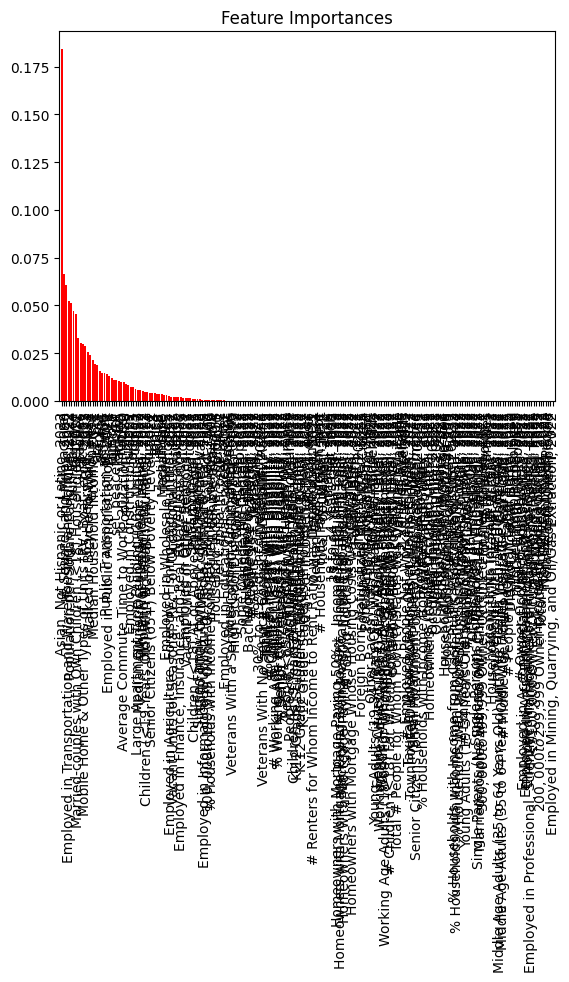

In [27]:
importances = xgb_optimized.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], color='r', align='center')
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

### Find best number of features and cross-validation folds

In [28]:
# Empty list to store and run different cv scores
cv_scores = []

for i in range(1, len(indices) + 1):
    # Select the top 'i' features
    top_features = [X_train.columns[indices[j]] for j in range(i)]
    
    # Create the training data using the selected features
    X_train_top = X_train_scaled[:, indices[:i]]
    
    # Initialize the model with the best parameters
    model = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42)
    
    # Perform cv at 5 and store the mean score
    scores = cross_val_score(model, X_train_top, Y_train, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(scores.mean())

# Which number of features gives the highest cv score?
optimal_features = np.argmax(cv_scores) + 1 
optimal_score = cv_scores[optimal_features - 1]

print(f"Optimal number of features: {optimal_features}")
print(f"Highest CV accuracy: {optimal_score:.2f}%")

Optimal number of features: 143
Highest CV accuracy: -0.12%


### Plot

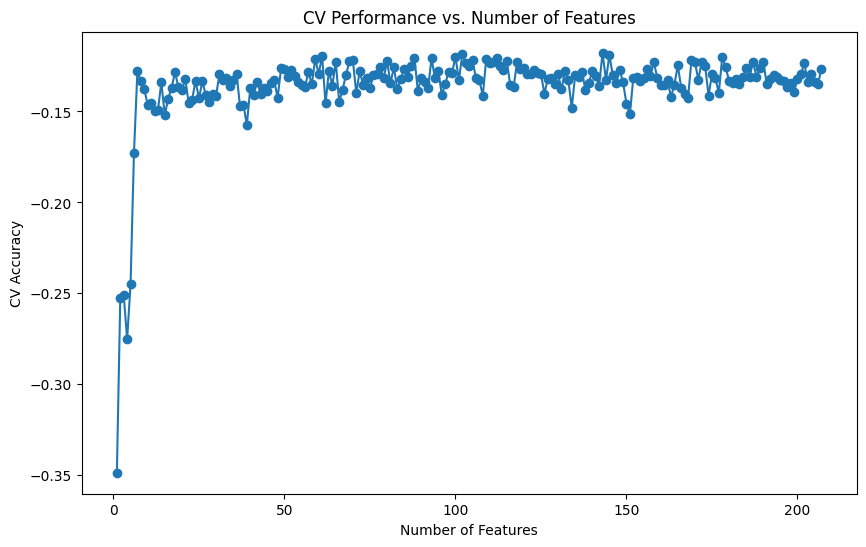

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(indices) + 1), cv_scores, marker='o')
plt.xlabel('Number of Features')
plt.ylabel('CV Accuracy')
plt.title('CV Performance vs. Number of Features')
plt.show()

### Re-run with best features

In [30]:
# Select optimal features
top_features_indices = indices[:optimal_features]
X_train_optimal = X_train_scaled[:, top_features_indices]
X_test_optimal = X_test_scaled[:, top_features_indices]

# Train the model using the selected subset of features
model_optimal = XGBRegressor(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42)
model_optimal.fit(X_train_optimal, Y_train)

# Evaluate the model on the test set
y_pred_optimal = model_optimal.predict(X_test_optimal)
mse_optimal = mean_squared_error(Y_test, y_pred_optimal)
accuracy_optimal = 100 - mse_optimal

print(f"Test set accuracy with optimal number of features ({optimal_features}): {accuracy_optimal:.2f}%")

Test set accuracy with optimal number of features (143): 99.86%


In [31]:
predictions_xgb = pd.DataFrame({'Actual': Y_test, 'Predicted': y_pred_optimal})

In [32]:
ZIP_results_xgb = pd.merge(predictions_xgb, data[['ZCTA', 'month']], left_index=True, right_index=True)

In [33]:
ZIP_results_xgb = ZIP_results_xgb[ZIP_results_xgb['Predicted'] > 0]

In [34]:
mse_xgb = mean_squared_error(Y_test, y_pred_optimal)

print('Mean Squared Error:', mse_xgb)

Mean Squared Error: 0.14391903029734696


In [35]:
'''
output_directory_1 = os.path.join(project_root_dir, '3_Models')
output_filename_1 = "xgb_lag.csv"
output_path_1 = os.path.join(output_directory_1, output_filename_1)

dump(model_optimal, output_path_1)
'''

'\noutput_directory_1 = os.path.join(project_root_dir, \'3_Models\')\noutput_filename_1 = "xgb_lag.csv"\noutput_path_1 = os.path.join(output_directory_1, output_filename_1)\n\ndump(model_optimal, output_path_1)\n'

# Evaluation and Comparison of Lag models

In [36]:
# Print MSE of both models

print('Mean Squared Error Random Forest:', mse_gs)
print('Mean Squared Error XGBoost:', mse_xgb)

Mean Squared Error Random Forest: 0.1500846024668718
Mean Squared Error XGBoost: 0.14391903029734696


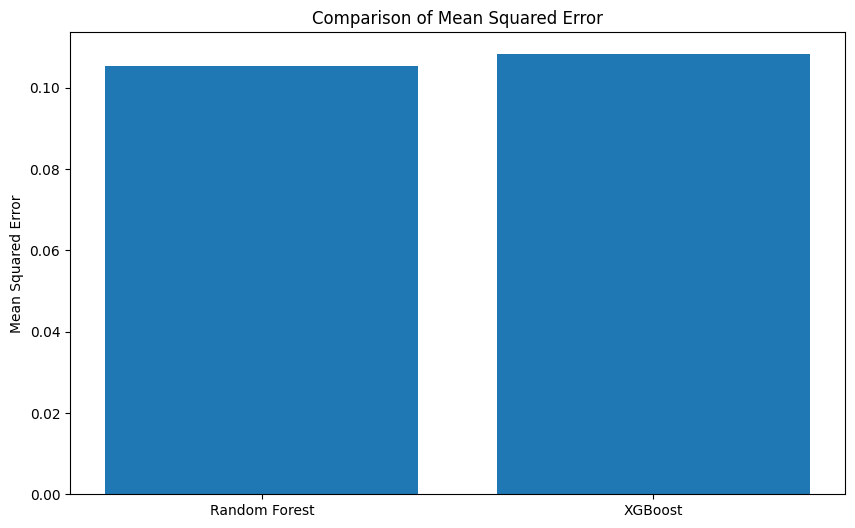

In [39]:
# Compare MSE of the models in one plot

plt.figure(figsize=(10, 6))
plt.bar(['Random Forest', 'XGBoost'], [mse_gs, mse_xgb])
plt.ylabel('Mean Squared Error')
plt.title('Comparison of Mean Squared Error')
plt.show()

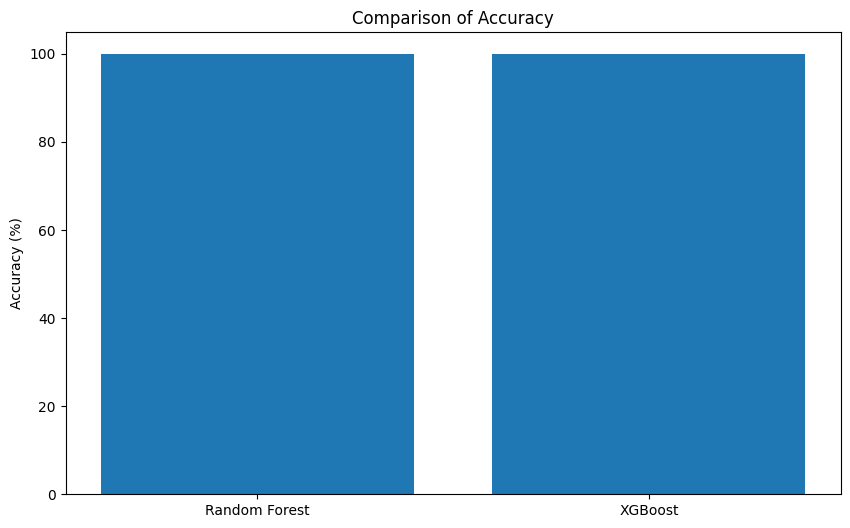

In [41]:
# Compare the accuracy of both models

accuracy_rf = 100 - mse_gs
accuracy_xgb = 100 - mse_xgb

plt.figure(figsize=(10, 6))
plt.bar(['Random Forest', 'XGBoost'], [accuracy_rf, accuracy_xgb])
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Accuracy')
plt.show()